# JOUR 1 — Préparation des données : que peut-on faire AVANT le split ?

## Fil rouge : maintenance prédictive industrielle — AI4I

### 1. Contexte de la base
Nous travaillons sur **AI4I 2020 Predictive Maintenance**, un jeu de données industriel de **10 000 observations** décrivant les conditions de fonctionnement de machines.  
Pour rendre le nettoyage réellement praticable en classe, la version pédagogique utilisée ici contient volontairement quelques **valeurs manquantes, doublons, incohérences de catégories et valeurs impossibles**.

### 2. Objectif du Jour 1
Aujourd'hui, nous ne construisons pas encore de modèle. Nous voulons répondre à la question :

> **Que puis-je corriger sur la base entière AVANT de séparer TRAIN / VALIDATION / TEST, sans provoquer de fuite de données ?**

Nous allons donc :
**charger → comprendre → auditer → détecter → nettoyer les erreurs factuelles → explorer → exporter.**

### 3. Dictionnaire des variables

| Variable | Signification | Rôle possible |
|---|---|---|
| `UDI` | identifiant unique de ligne | identifiant, à exclure du modèle |
| `Product ID` | identifiant du produit | identifiant, à exclure du modèle |
| `Type` | qualité/type du produit : L, M ou H | variable catégorielle |
| `Air temperature [K]` | température de l'air en Kelvin | variable explicative |
| `Process temperature [K]` | température du procédé en Kelvin | variable explicative |
| `Rotational speed [rpm]` | vitesse de rotation | variable explicative |
| `Torque [Nm]` | couple mécanique | variable numérique / cible possible de régression |
| `Tool wear [min]` | durée d'usure de l'outil | variable explicative |
| `Machine failure` | panne globale : 0 = non, 1 = oui | **cible naturelle de classification** |
| `TWF` | Tool Wear Failure | type de panne |
| `HDF` | Heat Dissipation Failure | type de panne |
| `PWF` | Power Failure | type de panne |
| `OSF` | Overstrain Failure | type de panne |
| `RNF` | Random Failure | type de panne |

### 4. Point pédagogique fondamental
Nous distinguons deux familles d'opérations.

**Avant le split :** opérations fondées sur une règle certaine et indépendante des statistiques du dataset : doublons exacts, espaces/casse, identifiants inutiles, valeurs physiquement impossibles connues par règle métier.

**Après le split :** opérations qui doivent *apprendre* un paramètre : moyenne, médiane, écart-type, IQR, Z-score, scaler, catégories d'un encodeur, PCA, sélection de variables, etc.

**Règle à retenir :** si une opération apprend une information statistique à partir des observations, on attend le split et on l'ajuste sur **TRAIN uniquement**.

## 1. Charger et visualiser la base

On commence toujours par comprendre ce que l'on a reçu, sans modifier la donnée.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("AI4I_J1_BRUT_PEDAGOGIQUE.csv")
if not path.exists():
    path = Path("/mnt/data/AI4I_J1_BRUT_PEDAGOGIQUE.csv")

df = pd.read_csv(path)
print("Dimensions :", df.shape)
display(df.head())
display(df.sample(5, random_state=42))

/home/oai/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-_mdrmg_6 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Dimensions : (10035, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551.0,42.8,0.0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3.0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5.0,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433.0,39.5,7.0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9.0,0,0,0,0,0,0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9727,9728,L56907,L,298.8,309.8,1461.0,39.4,141.0,0,0,0,0,0,0
6618,6619,M21478,M,301.6,310.6,1309.0,65.8,75.0,1,0,0,1,0,0
4441,4442,L51621,L,302.5,310.2,1329.0,50.6,148.0,1,0,1,0,0,0
7500,7501,L54680,L,300.2,311.8,1410.0,51.4,189.0,0,0,0,0,0,0
9241,9242,L56421,L,298.1,308.7,1683.0,29.1,161.0,0,0,0,0,0,0


### Comment lire cette première sortie ?
La version brute pédagogique contient **10 035 lignes et 14 colonnes**. Les 35 lignes supplémentaires sont volontaires : elles permettront de détecter de vrais doublons.

À ce stade, **on ne modifie rien**. `head()` et `sample()` servent seulement à regarder la forme des données, les unités, les catégories et les premières incohérences possibles.

## 2. Structure : lignes, colonnes et types

Questions à poser :
- Combien d'observations ?
- Combien de variables ?
- Quelles variables sont numériques/catégorielles ?
- Une colonne a-t-elle un type incohérent ?

In [2]:
print(df.info())
display(pd.DataFrame({
    "type": df.dtypes.astype(str),
    "nb_uniques": df.nunique(dropna=False)
}))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10035 non-null  int64  
 1   Product ID               10035 non-null  object 
 2   Type                     9985 non-null   object 
 3   Air temperature [K]      9955 non-null   float64
 4   Process temperature [K]  9954 non-null   float64
 5   Rotational speed [rpm]   9965 non-null   float64
 6   Torque [Nm]              9965 non-null   float64
 7   Tool wear [min]          9975 non-null   float64
 8   Machine failure          10035 non-null  int64  
 9   TWF                      10035 non-null  int64  
 10  HDF                      10035 non-null  int64  
 11  PWF                      10035 non-null  int64  
 12  OSF                      10035 non-null  int64  
 13  RNF                      10035 non-null  int64  
dtypes: float64(5), int64(7

,type,nb_uniques
UDI,int64,10000
Product ID,object,10000
Type,object,7
Air temperature [K],float64,94
Process temperature [K],float64,83
Rotational speed [rpm],float64,942
Torque [Nm],float64,579
Tool wear [min],float64,248
Machine failure,int64,2
TWF,int64,2


### Interprétation de la structure
On observe des variables numériques (`float64`, `int64`) et des variables catégorielles (`object`). `UDI` et `Product ID` ont pratiquement une valeur différente par observation : ce sont des **identifiants**, pas des mesures physiques.

`Type` possède ici plus de modalités qu'attendu. C'est un signal d'audit : il faut vérifier si des espaces ou différences de casse ont créé de fausses catégories.

## 3. Audit des valeurs manquantes

À ce stade, **on détecte et on quantifie**. On ne remplit pas encore par moyenne/médiane : la valeur d'imputation devra être apprise sur TRAIN après le split.

In [3]:
missing = pd.DataFrame({
    "nombre": df.isna().sum(),
    "pourcentage": (100*df.isna().mean()).round(2)
}).sort_values("nombre", ascending=False)
display(missing[missing["nombre"] > 0])

,nombre,pourcentage
Process temperature [K],81,0.81
Air temperature [K],80,0.80
Rotational speed [rpm],70,0.70
Torque [Nm],70,0.70
Tool wear [min],60,0.60
Type,50,0.50


### Interprétation — valeurs manquantes
Les valeurs manquantes représentent moins de 1 % par variable concernée. **Nous les détectons aujourd'hui mais nous ne calculons pas encore de moyenne ou médiane pour les remplacer.**

Pourquoi ? Une médiane calculée sur toute la base utiliserait indirectement des informations provenant des futures données de validation/test. L'imputation statistique sera donc reprise **après le split au Jour 2**.

## 4. Doublons exacts — nettoyage factuel

Un doublon exact dû à une duplication technique peut être supprimé avant le split : il n'est pas nécessaire de calculer une statistique pour savoir que les deux lignes sont identiques.

Attention : deux lignes partageant seulement le même client/machine ne sont pas automatiquement des doublons.

In [4]:
print("Doublons exacts :", df.duplicated().sum())
df = df.drop_duplicates().copy()
print("Dimensions après suppression :", df.shape)

Doublons exacts : 35
Dimensions après suppression : (10000, 14)


### Interprétation — doublons
Nous trouvons **35 doublons exacts**. Après suppression, nous revenons à **10 000 observations**.

Ici la suppression avant split est légitime : reconnaître deux lignes strictement identiques ne nécessite ni moyenne, ni cible, ni apprentissage statistique.

## 5. Catégories incohérentes — correction factuelle

Ici `Type` doit prendre les modalités L, M ou H. Des espaces/casses incohérents peuvent être corrigés par une règle déterministe.

In [5]:
print("Avant :", df["Type"].value_counts(dropna=False).to_dict())

df["Type"] = df["Type"].astype("string").str.strip().str.upper()
df["Type"] = df["Type"].replace({"<NA>": pd.NA})

print("Après :", df["Type"].value_counts(dropna=False).to_dict())

Avant : {'L': 5957, 'M': 2978, 'H': 997, nan: 50, 'M ': 6, 'h': 6, ' l': 6}
Après : {'L': 5963, 'M': 2984, 'H': 1003, <NA>: 50}


### Interprétation — catégories
Avant correction, `Type` contient notamment `M `, `h` et ` l`. Ce ne sont pas de nouveaux types de machines : ce sont des problèmes de **casse et d'espaces**.

Après `strip()` + `upper()`, on retrouve les trois modalités attendues **L, M, H**, tout en conservant les valeurs réellement manquantes.

## 6. Valeurs impossibles / anomalies manifestes

On distingue deux situations :

**A. Erreur certaine par règle métier** → on peut la corriger/marquer avant split.  
Exemples pédagogiques ici : vitesse négative, couple négatif, usure codée `9999`.

**B. Valeur seulement “rare” statistiquement** → ne pas la supprimer maintenant.  
Pour IQR/Z-score, les seuils seront calculés sur TRAIN au Jour 2.

Ici nous transformons les erreurs certaines en `NaN`. Leur imputation sera faite plus tard, après le split.

In [6]:
checks = {
    "vitesse_negative": (df["Rotational speed [rpm]"] < 0).sum(),
    "couple_negatif": (df["Torque [Nm]"] < 0).sum(),
    "usure_sentinelle": (df["Tool wear [min]"] == 9999).sum()
}
print(checks)

df.loc[df["Rotational speed [rpm]"] < 0, "Rotational speed [rpm]"] = np.nan
df.loc[df["Torque [Nm]"] < 0, "Torque [Nm]"] = np.nan
df.loc[df["Tool wear [min]"] == 9999, "Tool wear [min]"] = np.nan

{'vitesse_negative': np.int64(8), 'couple_negatif': np.int64(8), 'usure_sentinelle': np.int64(8)}


### Interprétation — anomalies manifestes
Nous détectons **8 vitesses négatives, 8 couples négatifs et 8 valeurs sentinelles d'usure**. Ces valeurs ont été introduites dans la version pédagogique pour illustrer une erreur certaine.

Nous les transformons en `NaN` au lieu d'inventer une valeur. Leur remplacement statistique sera appris plus tard sur TRAIN.

⚠️ Ce cas est différent d'un **outlier statistique**. Une vitesse élevée mais physiquement possible ne doit pas être supprimée simplement parce qu'elle est rare. Un seuil IQR ou Z-score appris à partir des données doit être traité après le split.

## 7. Colonnes inutiles et colonnes dangereuses

- `UDI` et `Product ID` sont des identifiants : ils n'expriment pas directement l'état physique de la machine.
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` décrivent des types de panne. Si notre cible future est `Machine failure`, les mettre dans X créerait une **fuite de cible**.

Nous ne sommes pas obligés de supprimer physiquement toutes ces colonnes du CSV : nous pouvons les conserver pour traçabilité, puis les exclure explicitement de X au Jour 2.

In [7]:
id_cols = ["UDI", "Product ID"]
failure_detail_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

display(df[id_cols + ["Machine failure"] + failure_detail_cols].head())
print("Ces colonnes seront exclues de X au Jour 2.")

,UDI,Product ID,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,0,0,0,0,0,0
1,2,L47181,0,0,0,0,0,0
2,3,L47182,0,0,0,0,0,0
3,4,L47183,0,0,0,0,0,0
4,5,L47184,0,0,0,0,0,0


Ces colonnes seront exclues de X au Jour 2.


### Pourquoi ne pas utiliser toutes les colonnes ?
`UDI` et `Product ID` sont des identifiants. Pour prédire `Machine failure`, les colonnes `TWF`, `HDF`, `PWF`, `OSF`, `RNF` sont également dangereuses : elles décrivent directement les modes de défaillance.

Les utiliser comme prédicteurs de la panne globale reviendrait à donner au modèle une partie de la réponse : **target leakage**.

## 8. EDA : comprendre les distributions sans apprendre de transformation

Visualiser est utile pour comprendre la donnée. En revanche, une décision statistique comme “supprimer tout ce qui dépasse Q3 + 1.5×IQR” devra être **apprise sur TRAIN** si elle fait partie du preprocessing ML.

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],9920.0,300.003044,1.998738,295.3,298.3,300.1,301.5,304.5
Process temperature [K],9920.0,310.005323,1.483747,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],9922.0,1538.913122,179.197911,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],9922.0,39.986868,9.972362,3.8,33.2,40.1,46.7,76.6
Tool wear [min],9932.0,107.978756,63.678968,0.0,53.0,108.0,162.0,253.0


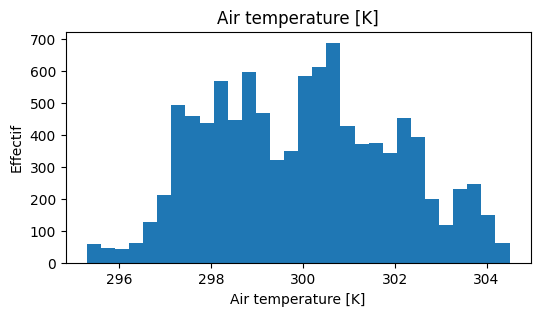

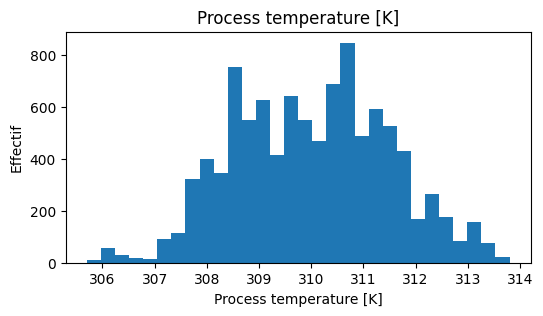

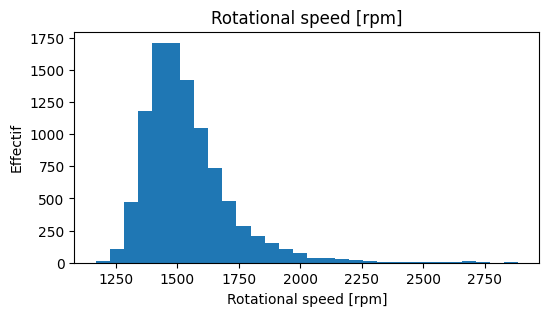

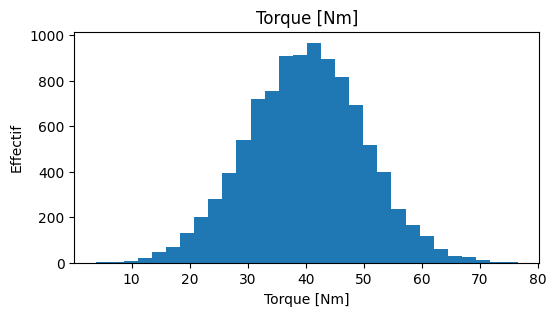

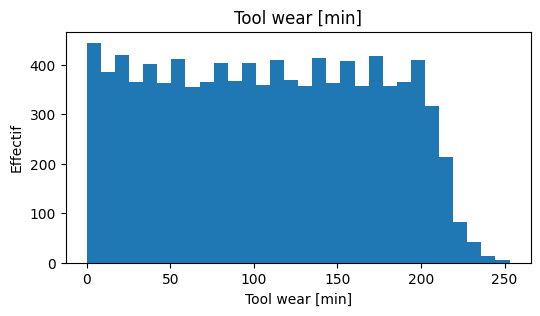

In [8]:
num_view = ["Air temperature [K]", "Process temperature [K]",
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

display(df[num_view].describe().T)

for col in num_view:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.show()

### Interprétation de l'EDA
Les statistiques descriptives donnent les ordres de grandeur des capteurs et permettent de repérer des distributions asymétriques ou des valeurs rares.

À ce stade, les graphiques servent à **comprendre**. Ils ne nous autorisent pas encore à apprendre un seuil IQR sur toute la base puis à supprimer des observations : ce seuil dépendrait de TRAIN + TEST.

## 9. Ce que nous NE faisons volontairement PAS au Jour 1

Nous avons détecté des valeurs manquantes, mais nous ne calculons pas encore leur médiane.

Nous ne faisons pas non plus :
- `StandardScaler.fit(...)`;
- `MinMaxScaler.fit(...)`;
- seuils IQR/Z-score appris sur toute la base ;
- PCA ;
- sélection de variables fondée sur y ;
- SMOTE ;
- tuning des modèles.

**Pourquoi ?** Parce que ces opérations apprennent des informations statistiques. Elles seront ajustées sur TRAIN uniquement après la séparation.

## 10. Export de la base préparée pour le Jour 2

Le fichier exporté est **factuellement nettoyé**, mais il peut encore contenir des `NaN`. C'est volontaire.

C'est précisément ce qui permettra demain de montrer correctement :

`split → fit preprocessing sur TRAIN → transform TRAIN et TEST avec les mêmes paramètres`.

In [9]:
prepared_path = Path("AI4I_J1_PREPARED.csv")
df.to_csv(prepared_path, index=False)
print("Export :", prepared_path)
print("Dimensions :", df.shape)
print("Valeurs manquantes restantes :", int(df.isna().sum().sum()))

Export : AI4I_J1_PREPARED.csv
Dimensions : (10000, 14)
Valeurs manquantes restantes : 434


### Conclusion et passage au Jour 2
Le fichier exporté contient **10 000 lignes, 14 colonnes et 434 valeurs manquantes restantes**. C'est volontaire.

Nous avons terminé le **nettoyage factuel**. Nous n'avons pas encore fait l'imputation statistique ni le scaling.

Le fichier `AI4I_J1_PREPARED.csv` devient donc le **point de départ officiel du Jour 2**.

# Bilan Jour 1

**Fait avant split :**
audit, structure, doublons exacts, standardisation factuelle de catégories, correction d'erreurs impossibles, identification des IDs et des risques de leakage, EDA.

**Reporté après split :**
imputation statistique, scaling, encodage appris, traitement statistique d'outliers, sélection/PCA et apprentissage.

Le Jour 2 repart exactement du fichier `AI4I_J1_PREPARED.csv`.